<a href="https://colab.research.google.com/github/lkmn-ai/logistic-regression-notes/blob/main/03_Digits_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Digits Data

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, multilabel_confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits

In [ ]:
digits = load_digits()
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [ ]:
digits.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
df_digits = pd.DataFrame(digits.data, columns=digits.feature_names)
df_digits['Target'] = digits.target
df_digits

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [ ]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

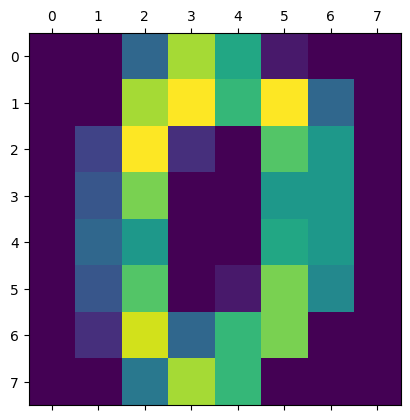

In [ ]:
plt.matshow(digits.images[0])

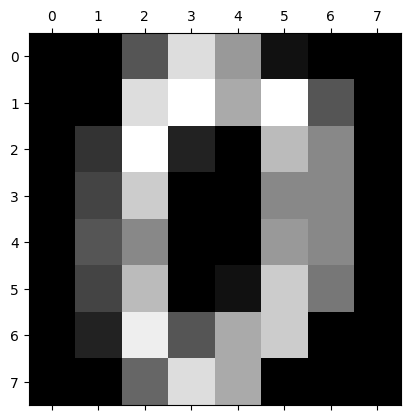

In [ ]:
plt.matshow(digits.images[0])
plt.gray()

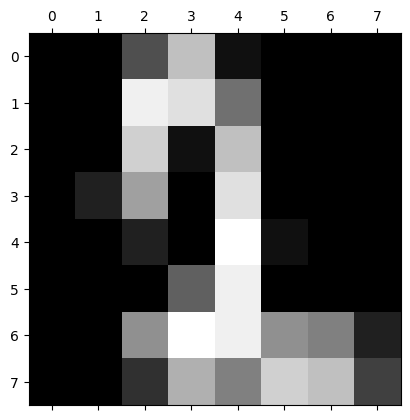

In [ ]:
plt.matshow(digits.images[12])
plt.gray()

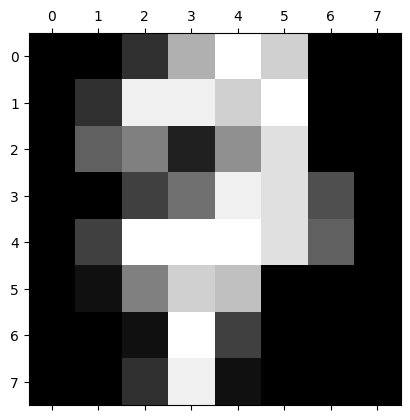

In [ ]:
plt.matshow(digits.images[112])
plt.gray()

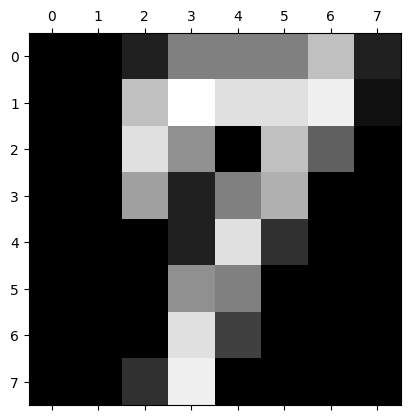

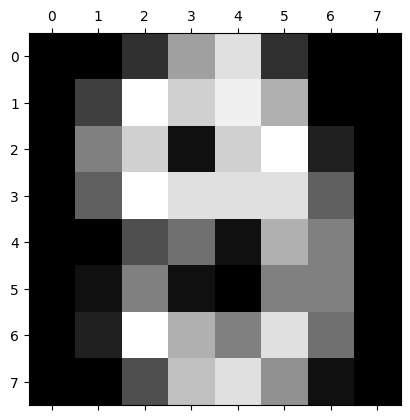

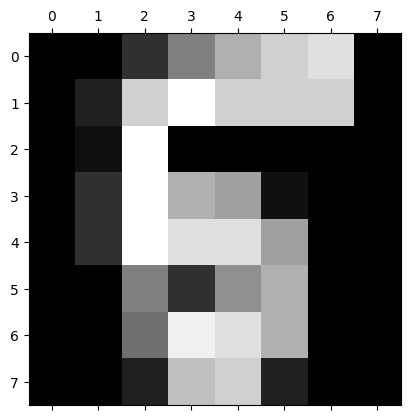

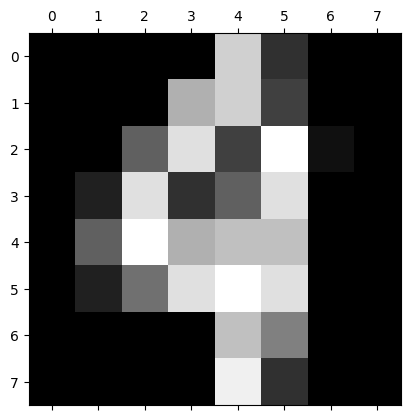

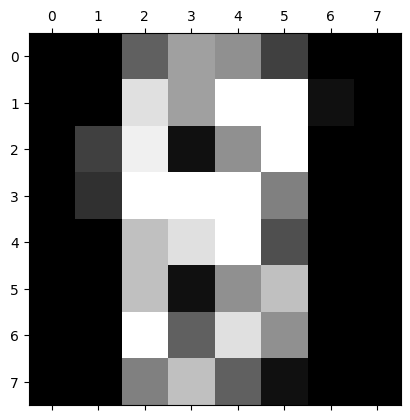

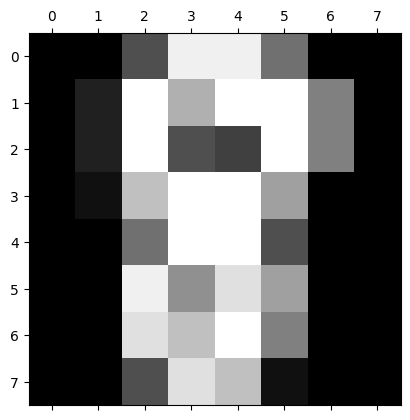

In [ ]:
for i in range(504,510):
    plt.matshow(digits.images[i])
    plt.gray()

### Train Test Split

In [ ]:
x = df_digits.drop('Target', axis =1)
y = df_digits['Target']

In [ ]:
y.value_counts(normalize=True)

Target
3    0.101836
1    0.101280
5    0.101280
4    0.100723
6    0.100723
9    0.100167
7    0.099610
0    0.099054
2    0.098497
8    0.096828
Name: proportion, dtype: float64

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=12, stratify=y)
y_train.value_counts(normalize=True)

Target
3    0.101830
1    0.101034
4    0.101034
6    0.101034
5    0.101034
9    0.100239
7    0.099443
0    0.098648
2    0.098648
8    0.097056
Name: proportion, dtype: float64

In [ ]:
y_test.value_counts(normalize=True)

Target
1    0.101852
3    0.101852
5    0.101852
7    0.100000
9    0.100000
6    0.100000
0    0.100000
4    0.100000
2    0.098148
8    0.096296
Name: proportion, dtype: float64

### Model Building

In [ ]:
log_clf = LogisticRegression(multi_class='ovr')
log_clf.fit(x_train, y_train)

LogisticRegression(multi_class='ovr')

### Evaluation

In [ ]:
def evaluation(string, model, ind_var, act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)

    acc_score = accuracy_score(act, pred)
    print('Accuracy Score :', acc_score)
    print('**'*20)

    cnf_matrix = confusion_matrix(act, pred)
    print('Confusion Matrix :\n', cnf_matrix)
    print('**'*20)

    multilabel_cnf_matrix = multilabel_confusion_matrix(act, pred)
    print('Multi Label Confusion Matrix :\n', multilabel_cnf_matrix)
    print('**'*20)

    clf_report = classification_report(act, pred)
    print('Classification Report :\n', clf_report)
    print('**'*20)

    return pred

y_pred = evaluation('Test Data Evaluation', log_clf, x_test, y_test)

***************Test Data Evaluation***************
Accuracy Score : 0.9611111111111111
****************************************
Confusion Matrix :
 [[54  0  0  0  0  0  0  0  0  0]
 [ 0 48  0  1  0  1  2  0  1  2]
 [ 0  1 50  1  0  0  0  0  1  0]
 [ 0  0  0 52  0  1  0  0  1  1]
 [ 0  0  0  0 54  0  0  0  0  0]
 [ 0  0  0  0  0 53  0  0  1  1]
 [ 0  1  0  0  0  0 53  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  0]
 [ 0  4  0  0  0  0  0  0 47  1]
 [ 0  0  0  0  0  0  0  0  0 54]]
****************************************
Multi Label Confusion Matrix :
 [[[486   0]
  [  0  54]]

 [[479   6]
  [  7  48]]

 [[487   0]
  [  3  50]]

 [[483   2]
  [  3  52]]

 [[486   0]
  [  0  54]]

 [[483   2]
  [  2  53]]

 [[484   2]
  [  1  53]]

 [[486   0]
  [  0  54]]

 [[484   4]
  [  5  47]]

 [[481   5]
  [  0  54]]]
****************************************
Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1 

In [ ]:
y_pred_train = evaluation('Train Data Evaluation', log_clf, x_train, y_train)

**************Train Data Evaluation***************
Accuracy Score : 0.9968178202068417
****************************************
Confusion Matrix :
 [[124   0   0   0   0   0   0   0   0   0]
 [  0 127   0   0   0   0   0   0   0   0]
 [  0   0 124   0   0   0   0   0   0   0]
 [  0   0   0 128   0   0   0   0   0   0]
 [  0   0   0   0 127   0   0   0   0   0]
 [  0   0   0   0   0 127   0   0   0   0]
 [  0   0   0   0   0   0 127   0   0   0]
 [  0   0   0   0   0   0   0 125   0   0]
 [  0   1   0   1   0   0   0   0 120   0]
 [  0   0   0   0   0   0   0   0   2 124]]
****************************************
Multi Label Confusion Matrix :
 [[[1133    0]
  [   0  124]]

 [[1129    1]
  [   0  127]]

 [[1133    0]
  [   0  124]]

 [[1128    1]
  [   0  128]]

 [[1130    0]
  [   0  127]]

 [[1130    0]
  [   0  127]]

 [[1130    0]
  [   0  127]]

 [[1132    0]
  [   0  125]]

 [[1133    2]
  [   2  120]]

 [[1131    0]
  [   2  124]]]
****************************************
Classif

In [ ]:
Step: 1
So first we will load the data
digits = load_digits()
digits

Step: 2
then search for the .key() where you will find the description of the data
digits.keys()
print(digits.DESCR)

Step: 3
Then create the Dataframe
pd.DataFrame(data is rows and columns is feature names)
Example: pd.DataFrame(data=digits['data'], columns=digits['feature_names'])

.info(), .describe(), .isnull().sum(), .value_counts(), kdeplot(), boxplot(), .unique(), .nunique(),
if there is no values we need to take the median of that and add it in place of the question mark

Step: 4
Then add the target values (species or target) at the last column
df_digits['Target'] = digits.target

Step: 5
Train test split data
so before training the data you see the tabular column there is target values, and for x we need to drop the the target values
# x = df_digits.drop('Target', axis =1)
# y = df_digits['Target']

so now it is ready to build the model, we need to split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=12, stratify=y)

Step: 6
Build the model
log = LogisticRegression()

then train it using x_train data and y test data
log.fit(x_train, y_train)

Step: 7
pred the x_test data
y_pred = log.predict(x_test)
after that you can do whatever operations needed

correlation why we use out of so many features which is very important for target year and area is more proportional to price but we need to do multi colinearity for reducing that one feature or Lasso Regression we can do,
before training the model we need to drop the feature